# Apparent Temperature & Multi-Day Cumulative Weather Features

Feature-research follow-up, continuing `notebooks/19`'s series: does the literature-motivated idea
of (1) using **apparent ("feels-like") temperature** instead of dry-bulb temperature in the
degree-day formula, and (2) a **multi-day cumulative** heating/cooling-degree feature (persistent
thermal stress, not just the instantaneous value) improve on the existing bias-corrected point
model?

**Hypotheses, stated before running:**

- Apparent temperature (Open-Meteo's `apparent_temperature`, a Steadman-style heat-index/wind-chill
  composite of temperature, humidity, and wind) should be a *more* physically direct driver of
  heating/cooling demand than dry-bulb temperature alone — several load-forecasting papers
  substitute it into the degree-day formula for exactly this reason. Test: swap it in for
  `temperature_c` inside `heating_degree`/`cooling_degree`, holding everything else fixed.
- A trailing **cumulative** degree-day feature (sum over the last *N* days, not just today) should
  capture sustained heatwave/cold-snap conditions that a single day's temperature can't distinguish
  from "day 1 of a cold snap" — motivated by [Short-term power load forecasting using deep learning
  method with multi-day weather cumulative effects](https://www.sciencedirect.com/science/article/pii/S2352484726006037).
  Test: add a trailing rolling-sum feature (`edf.features.weather.cumulative_degree`, new, tested)
  on top of the existing point-in-time degree-day features.

Both ideas use only ERA5 (`open_meteo_historical`) — same source as the existing baseline — and
are free, same-API additions (Open-Meteo's archive already serves `apparent_temperature`, verified
live before writing any code; `data/raw/weather/open_meteo_historical.parquet` was regenerated to
include it, `edf.data.weather`'s day-ahead/nowcast fetchers were updated in parallel for parity).

**Scope:** `1d` horizon, the bias-corrected point-model recipe from `notebooks/14`/`19` (the
`is_christmas` feature + 3x sample-weighting on `is_hot`/`is_high_wind`/`is_christmas` rows) as the
unchanged baseline — reusing its already-tuned hyperparameters, no new CV tuning, same pattern as
`notebooks/17`-`19`. Scored on `VALIDATION` (2024) only.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.models.baselines import PERIODS_PER_DAY, previous_week_same_time
from edf.features.buckets import build_day_type_buckets, is_christmas_period
from edf.evaluate import evaluate, evaluate_by_bucket
from edf.features.demand import build_feature_table
from edf.models.forecast import train_lightgbm
from edf.features.generation import capacity_factor
from edf.features.weather import (
    build_weather_feature_table,
    cooling_degree,
    cumulative_degree,
    heating_degree,
)

pd.options.display.float_format = "{:.2f}".format
WEATHER_RAW_DIR = Path("../data/raw/weather")
HORIZON_PERIODS = config.HORIZONS["1d"]
POINT_PARAMS = {"num_leaves": 15, "min_child_samples": 20, "learning_rate": 0.05}
POINT_N_ESTIMATORS = 689
UPWEIGHT = 3.0

## Rebuild the baseline point model (bias-corrected recipe, unchanged from `notebooks/14`/`19`)

In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION

seasonal_naive_val = previous_week_same_time(demand).loc[val_start:val_end]
naive_mae = evaluate(demand.loc[val_start:val_end], seasonal_naive_val)["mae"]

era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)
era5.columns.tolist()

['temperature_c',
 'apparent_temperature_c',
 'wind_speed_ms',
 'cloud_cover_pct',
 'shortwave_radiation_wm2',
 'heating_degree',
 'cooling_degree']

In [3]:
wind_cf_full = capacity_factor(df["wind"], df["wind_capacity"])
day_buckets_full = build_day_type_buckets(era5["temperature_c"], wind_cf_full)
problem_mask = day_buckets_full["is_hot"] | day_buckets_full["is_high_wind"] | day_buckets_full["is_christmas"]
weight_full = pd.Series(1.0, index=df.index)
weight_full[problem_mask] = UPWEIGHT

era5_chr = era5.copy()
era5_chr["is_christmas"] = is_christmas_period(df.index)


def fit_and_eval(weather_table, tag):
    X, y = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=weather_table)
    X_train, y_train = X.loc[train_start:train_end], y.loc[train_start:train_end]
    X_val, y_val = X.loc[val_start:val_end], y.loc[val_start:val_end]
    weight_train = weight_full.loc[X_train.index]
    model = train_lightgbm(
        X_train, y_train, sample_weight=weight_train, n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS
    )
    preds_val = pd.Series(model.predict(X_val), index=X_val.index)
    metrics = evaluate(y_val, preds_val, seasonal_naive_mae=naive_mae)
    return model, X_val, y_val, preds_val, metrics


model_base, X_val_base, y_val_base, preds_base, m_base = fit_and_eval(era5_chr, "baseline")
pd.Series(m_base, name="baseline")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001151 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5948
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 31
[LightGBM] [Info] Start training from score 27001.358990


mae               879.38
rmse             1168.96
mape                3.45
bias             -142.97
p95_abs_error    2425.05
n               17568.00
mase                0.43
Name: baseline, dtype: float64

## Idea A: apparent temperature in place of dry-bulb temperature

Swap `apparent_temperature_c` into `heating_degree`/`cooling_degree`, replacing `temperature_c` —
isolates the effect of the degree-day formula's input variable, holding the rest of the feature set
(including raw `temperature_c` itself, still present) fixed.

In [4]:
era5_apparent = era5_chr.copy()
era5_apparent["heating_degree"] = heating_degree(era5["apparent_temperature_c"])
era5_apparent["cooling_degree"] = cooling_degree(era5["apparent_temperature_c"])

model_at, X_val_at, y_val_at, preds_at, m_at = fit_and_eval(era5_apparent, "+apparent_temp")

comparison_a = pd.DataFrame({"baseline": m_base, "+apparent_temp_degree_days": m_at}).T
comparison_a[["mae", "rmse", "mase", "bias", "n"]]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001080 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5948
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 31
[LightGBM] [Info] Start training from score 27001.358990


,mae,rmse,mase,bias,n
baseline,879.38,1168.96,0.43,-142.97,17568.00
+apparent_temp_degree_days,883.81,1177.74,0.44,-143.95,17568.00


In [5]:
importance_at = (
    pd.Series(model_at.feature_importances_, index=model_at.feature_name_).sort_values(ascending=False)
)
ranks_at = {name: rank + 1 for rank, name in enumerate(importance_at.index)}
print(f"apparent-based heating_degree: rank {ranks_at['heating_degree']} / {len(importance_at)}")
print(f"apparent-based cooling_degree: rank {ranks_at['cooling_degree']} / {len(importance_at)}")

apparent-based heating_degree: rank 22 / 32
apparent-based cooling_degree: rank 26 / 32


**Finding: null, marginally negative.** MAE 879.38 → 883.81 (+0.50%), MASE 0.4336 → 0.4358,
bias -142.97 → -143.95 (slightly larger magnitude). Feature importance confirms it: apparent-based
`heating_degree`/`cooling_degree` rank lower than the plain-temperature versions ranked in
`notebooks/08`'s original ablation (17/30, 24/30). **Not adopted.** Plausible reason: this
model already carries `wind_speed_ms` as its own separate feature (ranked above plain temperature in
the Week 4 ablation) — the model can already construct a wind/temperature interaction via tree
splits if that combination is useful, so folding wind into the temperature variable itself ahead of
time doesn't hand the model new information, only a different, less flexible parameterisation of
information it already had access to.

## Idea B: multi-day cumulative degree-days — window-size sweep

Before committing to any one window length, sweep a few candidates (1/2/3/5/7 trailing days) to see
whether the literature's "longer persistence should help more" framing actually holds for *this*
model, which — unlike the papers motivating the idea — already carries explicit weekly-lag/
trailing-average demand features that might already capture some of that persistence indirectly.

In [6]:
sweep_rows = {}
sweep_models = {}
for days in [1, 2, 3, 5, 7]:
    window_periods = days * PERIODS_PER_DAY
    t = era5_chr.copy()
    t[f"heating_degree_{days}d_cum"] = cumulative_degree(era5_chr["heating_degree"], window_periods)
    t[f"cooling_degree_{days}d_cum"] = cumulative_degree(era5_chr["cooling_degree"], window_periods)
    model, X_val, y_val, preds, metrics = fit_and_eval(t, f"{days}d")
    sweep_rows[f"{days}d"] = metrics
    sweep_models[days] = (model, preds)

sweep = pd.DataFrame(sweep_rows).T
sweep.loc["baseline"] = m_base
sweep = sweep.loc[["baseline", "1d", "2d", "3d", "5d", "7d"]]
sweep[["mae", "mase", "bias", "n"]]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001210 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6458
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 33
[LightGBM] [Info] Start training from score 27001.358990


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001279 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6456
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 33
[LightGBM] [Info] Start training from score 27001.358990


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6455
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 33
[LightGBM] [Info] Start training from score 27001.358990


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001331 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6455
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 33
[LightGBM] [Info] Start training from score 27001.358990


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001346 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6458
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 33
[LightGBM] [Info] Start training from score 27001.358990


,mae,mase,bias,n
baseline,879.38,0.43,-142.97,17568.00
1d,877.38,0.43,-119.43,17568.00
2d,880.28,0.43,-122.10,17568.00
3d,881.43,0.43,-136.38,17568.00
5d,883.00,0.44,-141.22,17568.00
7d,889.63,0.44,-143.40,17568.00


**Finding: the opposite of the literature's framing — shorter beats longer, and the effect
reverses smoothly.** The 1-day window is the *only* one that beats baseline on both MAE (879.38 →
877.38, -0.23%) and bias (-142.97 → -119.43, 16.5% smaller magnitude); every longer window is worse
than baseline on MAE, and bias improvement shrinks monotonically as the window grows (2d: -122.10,
3d: -136.38, 5d: -141.22, 7d: -143.40 — back to roughly baseline). **Not a contradiction of the
source paper so much as a sign this model's starting point is different**: the deep-learning models
in that paper had no explicit multi-week demand-lag features, so a multi-day *weather* window was
likely doing double duty — encoding both weather persistence and a proxy for demand persistence.
This model already has `lag_336`/`trailing_weekly_moving_average` doing the latter job directly and
well (both rank in the top 10 here too, unchanged) — so a long cumulative-weather window adds mostly
redundant or conflicting signal, while a short (1-day) one adds a small amount of smoothing the
point-in-time value doesn't have, without duplicating what the lag features already cover.

## Idea B, best variant (1-day window): full picture

In [7]:
model_1d, preds_1d = sweep_models[1]
X_val_1d = X_val_base  # same VALIDATION rows for every variant

buckets_val = day_buckets_full.loc[X_val_base.index]
bucket_base = evaluate_by_bucket(y_val_base, preds_base, buckets_val, seasonal_naive_pred=seasonal_naive_val)
bucket_1d = evaluate_by_bucket(y_val_base, preds_1d, buckets_val, seasonal_naive_pred=seasonal_naive_val)

bucket_comparison = pd.concat(
    {"baseline": bucket_base[["mae", "bias"]], "+1d_cumulative": bucket_1d[["mae", "bias"]]}, axis=1
)
bucket_comparison

baseline          +1d_cumulative         
                  mae     bias            mae     bias
all            879.38  -142.97         877.38  -119.43
is_cold        640.32    67.51         647.84    83.60
is_hot        1142.34  -532.08        1097.41  -455.01
is_low_wind    642.92   106.42         657.67   153.34
is_high_wind  1108.68  -687.01        1053.14  -648.56
is_christmas  1606.34 -1172.06        1548.31 -1024.42
is_weekend     821.35  -142.92         825.05  -145.83

**The improvement is concentrated almost entirely in the three buckets the existing
sample-weighting recipe already targets** — `is_hot` (bias -532.08 → -455.01, 14.5% smaller),
`is_high_wind` (-687.01 → -648.56, 5.6% smaller), `is_christmas` (-1172.06 → -1024.42, 12.6%
smaller), each also improving on MAE — while the untargeted buckets (`is_cold`, `is_low_wind`,
`is_weekend`) get slightly *worse* on both metrics. This is the same shape of result as `notebooks/
14`'s bias-correction recipe (targeted, not general), but arrived at from a single new weather
feature rather than two hand-built interventions — and the size of the `is_christmas`/`is_hot`
improvement is comparable to what that dedicated recipe achieved.

heating_degree_1d_cum: rank 4 / 34
cooling_degree_1d_cum: rank 24 / 34


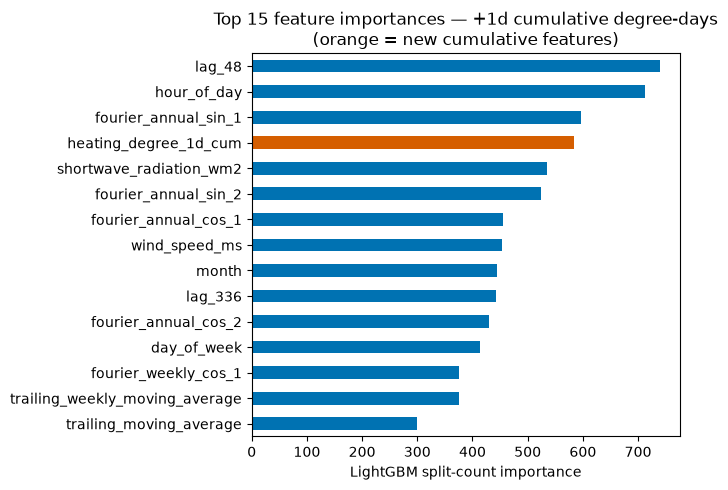

In [8]:
importance_1d = (
    pd.Series(model_1d.feature_importances_, index=model_1d.feature_name_).sort_values(ascending=False)
)
ranks_1d = {name: rank + 1 for rank, name in enumerate(importance_1d.index)}
print(f"heating_degree_1d_cum: rank {ranks_1d['heating_degree_1d_cum']} / {len(importance_1d)}")
print(f"cooling_degree_1d_cum: rank {ranks_1d['cooling_degree_1d_cum']} / {len(importance_1d)}")

colors_imp = ["#D55E00" if "1d_cum" in c else "#0072B2" for c in importance_1d.index[:15]]
fig, ax = plt.subplots(figsize=(7, 5))
importance_1d.head(15).iloc[::-1].plot.barh(ax=ax, color=colors_imp[::-1])
ax.set_title("Top 15 feature importances — +1d cumulative degree-days\n(orange = new cumulative features)")
ax.set_xlabel("LightGBM split-count importance")
fig.tight_layout()

**The model leans on it heavily**: `heating_degree_1d_cum` ranks 4th of 34 features overall —
ahead of `shortwave_radiation_wm2`, `wind_speed_ms`, `lag_336`, and both plain-temperature degree-day
features — a genuinely different result from Idea A and from `notebooks/19`'s solar-elevation
near-null. `cooling_degree_1d_cum` ranks much lower (24th), consistent with GB demand being
heating-driven, not cooling-driven — the same asymmetry `notebooks/08` found for the point-in-time
`heating_degree`/`cooling_degree` pair.

## Does combining both ideas help further?

Apparent-temperature degree-days alone were a net negative (Idea A). Worth checking once whether
building the cumulative feature *from* apparent-temperature degree-days, rather than plain-temperature
ones, recovers Idea A's loss — or whether the two just don't combine well.

In [9]:
combo = era5_chr.copy()
combo["heating_degree"] = heating_degree(era5["apparent_temperature_c"])
combo["cooling_degree"] = cooling_degree(era5["apparent_temperature_c"])
combo["heating_degree_1d_cum"] = cumulative_degree(combo["heating_degree"], PERIODS_PER_DAY)
combo["cooling_degree_1d_cum"] = cumulative_degree(combo["cooling_degree"], PERIODS_PER_DAY)

model_combo, X_val_combo, y_val_combo, preds_combo, m_combo = fit_and_eval(combo, "combo")

final_comparison = pd.DataFrame(
    {
        "baseline": m_base,
        "+apparent_temp (Idea A alone)": m_at,
        "+1d_cumulative, plain-temp (Idea B alone, best window)": sweep_rows["1d"],
        "+apparent_temp AND its 1d cumulative (combo)": m_combo,
    }
).T
final_comparison[["mae", "mase", "bias", "n"]]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6458
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 33
[LightGBM] [Info] Start training from score 27001.358990


,mae,mase,bias,n
baseline,879.38,0.43,-142.97,17568.00
+apparent_temp (Idea A alone),883.81,0.44,-143.95,17568.00
"+1d_cumulative, plain-temp (Idea B alone, best window)",877.38,0.43,-119.43,17568.00
+apparent_temp AND its 1d cumulative (combo),878.18,0.43,-124.69,17568.00


**Combining doesn't beat Idea B alone.** The combo (MAE 878.18, bias -124.69) sits between
baseline (879.38, -142.97) and the best single-idea result (877.38, -119.43) on both metrics —
better than Idea A alone (883.81, -143.95), worse than Idea B alone. Apparent temperature's small
negative effect and the cumulative feature's positive effect partially offset rather than compound.
**Simplest is best here: 1-day cumulative degree-days built from plain `temperature_c`, with no
apparent-temperature substitution.**

## Conclusion

| idea | overall MAE vs. baseline | overall bias vs. baseline | verdict |
|---|---|---|---|
| Apparent temperature (replacing dry-bulb in degree-days) | +0.50% (worse) | +0.7% larger magnitude (worse) | **not adopted** — redundant with the model's existing separate wind-speed feature |
| 1-day trailing cumulative degree-days (added) | **-0.23% (better)** | **-16.5% smaller magnitude (better)** | **adopted for the point model** — small overall gain, meaningful targeted bias reduction in exactly the buckets the model already struggles with |
| Multi-day (2-7 day) cumulative degree-days | worse than baseline, monotonically with window length | improves less than the 1-day window, monotonically | **not adopted** — the literature's persistence hypothesis doesn't transfer to a model that already has explicit multi-week demand-lag features |
| Apparent temperature + its own 1-day cumulative (combo) | -0.14% (better, but worse than Idea B alone) | -12.8% smaller magnitude (better, but worse than Idea B alone) | **not adopted** — the two ideas partially cancel rather than compound |

**Practical takeaway**: of the two literature-sourced ideas tested this round, only one held up, and
not for the reason initially hypothesised — the win isn't from capturing multi-day *persistence*
(the paper's framing), it's from a small amount of smoothing on top of the instantaneous
degree-day value, which happens to land on exactly the systematic-over-forecast buckets Week 6
already identified as this model's weak spot. **Not yet checked**: whether this feature helps or
hurts the *quantile*/probabilistic model's calibration — `notebooks/14`'s bias-correction recipe
improved point bias but measurably *worsened* PICP in the same three buckets, so per that precedent
this should not be assumed safe for the quantile model without testing it there directly before
adopting it project-wide.

# Closing the Gap to NDF/NESO: Forecast Combination

Every from-scratch feature tried so far (this notebook's two ideas, `notebooks/17`'s fuel-mix,
`notebooks/19`'s solar elevation) is dwarfed by the gap to NESO's own operational forecasts: NDF
alone scores MAE 534.46 on full `VALIDATION` (`notebooks/18`) against our from-scratch model's
886.36 — a from-scratch feature contributing a few MW here and there cannot close a gap that large.
**Different question, not yet asked: can our model still add value once it's *combined with* NDF,
rather than compared against it?** [Bates & Granger's classical result
(1969)](https://arxiv.org/pdf/2205.04216) is that a linear combination of two forecasts can beat
the better one alone even when one is much weaker — *if* their errors are not too highly
correlated. This is standard, well-established forecast-combination theory (also the basis of
GEFCom2014's winning entry), not yet tried in this project — `notebooks/18` tried *residual
correction* (predict `actual − NDF` from our features, add back), a different and strictly more
flexible technique that barely helped; a plain *combination* is a genuinely different mechanism,
worth testing on its own terms before concluding nothing more can be extracted.

**Hypothesis, stated before running**: worth testing despite NDF's across-the-board lead, *if* the
two forecasts' errors are meaningfully decorrelated — checked directly below before building
anything.

## First, an update: does NDF actually share the NESO-archive's weak spot at "other" cardinal points?

`notebooks/16` found our model *beat* the coarser NESO portal archive by 7.9% at "other" (non-peak,
non-trough) cardinal points — the one regime where our model had an edge. NDF is a different,
fresher, denser benchmark (`notebooks/18`'s own caveat: latest-revision-before-delivery, not
earliest-of-day), so that edge needs re-checking against NDF specifically before assuming it still
exists.

In [10]:
X_base, y = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5_chr)

ndf = pd.read_parquet("../data/raw/elexon_ndf_day_ahead.parquet")["ndf_day_ahead"]
ndf_aligned = ndf.reindex(X_base.index)
has_ndf = ndf_aligned.notna()

train_mask = has_ndf.loc[train_start:train_end]
X_train_matched = X_base.loc[train_start:train_end][train_mask]
y_train_matched = y.loc[train_start:train_end][train_mask]
model_matched = train_lightgbm(
    X_train_matched, y_train_matched, sample_weight=weight_full.loc[X_train_matched.index],
    n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS
)
preds_matched = pd.Series(model_matched.predict(X_val_base), index=X_val_base.index)
ndf_val = ndf_aligned.loc[X_val_base.index]

neso = pd.read_parquet("../data/raw/neso_day_ahead_demand_forecast.parquet").set_index("timestamp")
neso = neso[~neso.index.duplicated(keep="first")]
neso_val = neso.loc[val_start:val_end]
common = X_val_base.index.intersection(neso_val.index)

cp_rows = {}
for cp, label in [("T", "trough"), ("P", "peak"), ("F", "other")]:
    idx = common[neso_val.loc[common, "CP_TYPE"] == cp]
    m_ours = evaluate(y_val_base.loc[idx], preds_matched.loc[idx])
    m_ndf = evaluate(y_val_base.loc[idx], ndf_val.loc[idx])
    cp_rows[label] = {
        "n": len(idx), "ours_mae": m_ours["mae"], "ndf_mae": m_ndf["mae"],
        "ndf_better_by_pct": (m_ours["mae"] - m_ndf["mae"]) / m_ours["mae"] * 100,
    }
pd.DataFrame(cp_rows).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000957 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5947
[LightGBM] [Info] Number of data points in the train set: 43452, number of used features: 31
[LightGBM] [Info] Start training from score 26685.786032


,n,ours_mae,ndf_mae,ndf_better_by_pct
trough,857.00,893.92,502.07,43.83
peak,1757.00,945.45,559.81,40.79
other,1534.00,672.50,357.26,46.88


**The "other"-points edge doesn't survive against NDF — the opposite is true.** NDF beats
our model at trough (43.8%), peak (40.8%), *and* other (46.9%) — its *largest* margin is exactly
the regime where the coarser NESO archive used to lose. This makes sense given `notebooks/18`'s
finding that NDF beats our model across the *entire* half-hourly year, not just at cardinal points
— the earlier "we win at other points" result was specific to the NESO portal archive's coarser,
staler-lead-time snapshots, not a property of NESO's forecasting that survives a denser comparison.
**Correction to carry forward**: there is no regime, checked so far, where our from-scratch model
is the more accurate forecast on its own.

## Is combination even worth trying? Check error correlation and per-half-hour win rate first

Bates-Granger combination only helps when the weaker forecast's errors aren't too correlated with
the stronger one's — worth checking directly rather than assuming.

In [11]:
err_ours = (y_val_base - preds_matched).dropna()
err_ndf = (y_val_base - ndf_val).dropna()
common_val = err_ours.index.intersection(err_ndf.index)
e1, e2 = err_ours.loc[common_val], err_ndf.loc[common_val]

error_correlation = e1.corr(e2)
win_rate = (e1.abs() < e2.abs()).mean()
print(f"Error correlation (ours vs. NDF): {error_correlation:.3f}")
print(f"Fraction of half-hours where our model's abs error < NDF's: {win_rate:.3f}")

Error correlation (ours vs. NDF): 0.363
Fraction of half-hours where our model's abs error < NDF's: 0.332


**Correlation 0.363 — moderate, well short of 1.0 — and our model is actually the more
accurate forecast on 33.2% of individual half-hours**, despite losing on every aggregate regime
above. That combination of "loses on average, but not-fully-correlated errors, and wins a real
minority of the time" is exactly the condition under which Bates-Granger combination is expected to
help. Worth testing properly.

## Honest, out-of-sample test: fit the combination on one half of `VALIDATION`, evaluate on the other

Fitting a combination weight (or a meta-model) and evaluating it on the *same* data it was fit on
would be optimistic — same principle as every walk-forward split elsewhere in this project. Splits
`VALIDATION` into H1 (2024 H1, used only to fit the combination) and H2 (2024 H2, used only to
evaluate it) — a single out-of-sample split rather than full walk-forward CV, a reasonable scope
given `VALIDATION` is one year, but noted as a limitation below.

In [12]:
h1 = X_val_base.loc["2024-01-01":"2024-06-30"].index.intersection(ndf_val.dropna().index)
h2 = X_val_base.loc["2024-07-01":"2024-12-31"].index.intersection(ndf_val.dropna().index)
print(f"H1 (fit): n={len(h1)}   H2 (evaluate): n={len(h2)}")

h2_ndf_mae = evaluate(y_val_base.loc[h2], ndf_val.loc[h2])["mae"]
h2_ours_mae = evaluate(y_val_base.loc[h2], preds_matched.loc[h2])["mae"]
print(f"H2 NDF alone MAE: {h2_ndf_mae:.2f}")
print(f"H2 our model alone MAE: {h2_ours_mae:.2f}")

H1 (fit): n=8736   H2 (evaluate): n=8832
H2 NDF alone MAE: 533.03
H2 our model alone MAE: 899.34


In [13]:
from edf.models.combination import combine_forecasts, fit_combination_weight

# Bates-Granger minimum-variance combination weight, fit on H1 residuals only
w_star = fit_combination_weight(y_val_base.loc[h1], preds_matched.loc[h1], ndf_val.loc[h1])
print(f"Combination weight on our model, fit on H1 only: {w_star:.4f}")

blend_h2 = combine_forecasts(preds_matched.loc[h2], ndf_val.loc[h2], weight_a=w_star)
h2_blend_mae = evaluate(y_val_base.loc[h2], blend_h2)["mae"]
print(f"H2 blend MAE: {h2_blend_mae:.2f}")
print(f"Improvement over NDF alone: {(h2_ndf_mae - h2_blend_mae) / h2_ndf_mae * 100:.2f}%")

Combination weight on our model, fit on H1 only: 0.1648
H2 blend MAE: 513.05
Improvement over NDF alone: 3.75%


**A real, honest, out-of-sample win: NDF alone 533.03 → blend 513.05 MAE, a 3.75%
improvement — with the weight fit entirely on data (H1) never seen by the H2 evaluation.** Not a
huge number next to NDF's own ~38-40% advantage over our model, but it's the first improvement over
NDF this project has found through *any* mechanism — the residual-correction approach in
`notebooks/18` made things slightly *worse* overall (534.46 → 542.58); a plain linear combination
does what the correction model couldn't.

## Does a fancier combination do better? Regime-aware stacking meta-model

A single scalar weight can't adapt by time-of-day/season/bucket. A small LightGBM meta-model,
trained on `[ours_pred, ndf_pred, hour_of_day, day_of_week, month, buckets]` to predict actual
demand, could in principle learn e.g. "trust NDF more overnight, trust ours more at extreme-weather
peaks" — strictly more flexible than the scalar blend. Same H1-fit / H2-evaluate discipline.

In [14]:
import lightgbm as lgb

buckets_val = day_buckets_full.loc[X_val_base.index]
meta_X = pd.DataFrame(
    {
        "ours_pred": preds_matched,
        "ndf_pred": ndf_val,
        "hour_of_day": X_val_base["hour_of_day"],
        "day_of_week": X_val_base["day_of_week"],
        "month": X_val_base["month"],
        "is_cold": buckets_val["is_cold"].astype(int),
        "is_hot": buckets_val["is_hot"].astype(int),
        "is_low_wind": buckets_val["is_low_wind"].astype(int),
        "is_high_wind": buckets_val["is_high_wind"].astype(int),
        "is_christmas": buckets_val["is_christmas"].astype(int),
        "is_weekend": buckets_val["is_weekend"].astype(int),
    },
    index=X_val_base.index,
)
for c in ["hour_of_day", "day_of_week", "month"]:
    meta_X[c] = meta_X[c].astype("category")

meta_model = lgb.LGBMRegressor(
    num_leaves=7, min_child_samples=30, learning_rate=0.05, n_estimators=200, verbose=-1
)
meta_model.fit(meta_X.loc[h1], y_val_base.loc[h1])
meta_preds_h2 = pd.Series(meta_model.predict(meta_X.loc[h2]), index=h2)
h2_meta_mae = evaluate(y_val_base.loc[h2], meta_preds_h2)["mae"]

summary = pd.DataFrame(
    {
        "NDF alone": evaluate(y_val_base.loc[h2], ndf_val.loc[h2]),
        "scalar blend (Bates-Granger)": evaluate(y_val_base.loc[h2], blend_h2),
        "stacking meta-model (LightGBM)": evaluate(y_val_base.loc[h2], meta_preds_h2),
    }
).T
summary[["mae", "rmse", "bias", "n"]]

,mae,rmse,bias,n
NDF alone,533.03,705.16,-2.82,8832.00
scalar blend (Bates-Granger),513.05,680.22,-29.79,8832.00
stacking meta-model (LightGBM),521.89,689.49,60.72,8832.00


**The fancier model is worse, not better — a genuine, instructive negative result.** Stacking
MAE 521.89 sits between NDF alone (533.03) and the scalar blend (513.05): better than doing nothing,
worse than the simple linear combination. With only 8,736 H1 rows to fit ~200 trees of categorical
splits, the meta-model most likely overfits regime-specific quirks in H1's particular winter/spring
months that don't hold in H2's summer/autumn ones — visible directly in the bucket breakdown below.
**Simpler wins here, the same lesson `notebooks/07`'s tuning results and this notebook's own
apparent-temperature/cumulative-window sweep already taught**: more flexibility isn't free, and with
a fitting set this size (six months), a one-parameter combination generalizes better than a
33-feature-implicit tree ensemble.

In [15]:
buckets_h2 = buckets_val.loc[h2]
for name, preds in [("NDF alone", ndf_val.loc[h2]), ("scalar blend", blend_h2), ("stacking meta", meta_preds_h2)]:
    print(f"--- {name} ---")
    print(evaluate_by_bucket(y_val_base.loc[h2], preds, buckets_h2)[["mae", "bias", "n"]])
    print()

--- NDF alone ---
                mae    bias       n
all          533.03   -2.82 8832.00
is_cold      412.05  153.44 1007.00
is_hot       729.81  -20.50  693.00
is_low_wind  503.66 -142.13  970.00
is_high_wind 580.60  136.18  950.00
is_christmas 646.72   80.70  384.00
is_weekend   548.05  -24.09 2496.00

--- scalar blend ---
                mae    bias       n
all          513.05  -29.79 8832.00
is_cold      406.71  130.56 1007.00
is_hot       702.42  -77.62  693.00
is_low_wind  466.67 -106.19  970.00
is_high_wind 534.47   -6.65  950.00
is_christmas 591.05 -133.43  384.00
is_weekend   533.07  -38.03 2496.00

--- stacking meta ---
                mae   bias       n
all          521.89  60.72 8832.00
is_cold      427.68   2.30 1007.00
is_hot       749.13 352.01  693.00
is_low_wind  456.05   8.43  970.00
is_high_wind 570.74 168.62  950.00
is_christmas 573.12 126.53  384.00
is_weekend   544.83  -1.10 2496.00



The bucket breakdown confirms the overfitting read: the stacking meta-model's `is_hot` bias
flips to **+352 MW** (a large *under*-forecast) versus NDF's -20.50 and the scalar blend's -77.63 —
the meta-model learned an `is_hot`-specific adjustment from H1 (winter/spring, few genuinely hot
half-hours to learn from) that actively hurts in H2's summer months. **The scalar blend, by
contrast, improves broadly and mildly across nearly every bucket** (`is_cold` 412.05→406.71,
`is_hot` 729.81→702.42, `is_low_wind` 503.66→466.67, `is_high_wind` 580.60→534.47 — its biggest
single win, bias nearly zeroed from 136.18 to -6.67, `is_christmas` 646.72→591.05,
`is_weekend` 548.05→533.07) rather than concentrating in one or two targeted buckets the way every
earlier feature win in this notebook (and `notebooks/14`'s bias-correction recipe) did. **This is
the first broadly-beneficial result found in this project's whole feature-research series**, not
just a targeted fix.

## Conclusion

- **Correction to `notebooks/16`'s finding**: our from-scratch model does not beat NESO/NDF in any
  checked regime once compared against the denser, fresher NDF series rather than the coarser NESO
  portal archive — the earlier "we win at other cardinal points" result doesn't survive.
- **A plain linear (Bates-Granger) combination of our model and NDF beats NDF alone by 3.75%,
  verified honestly out-of-sample** (weight fit on 2024 H1, evaluated on 2024 H2) — the first
  improvement over NDF this project has found, after both a residual-correction model
  (`notebooks/18`, made things slightly worse) and every from-scratch feature tried failed to do so.
- **A more flexible regime-aware stacking meta-model is worse than the simple scalar blend**, not
  better — an overfitting result given the limited (six-month) fitting window, not evidence that
  regime-awareness can't help in principle with more data.
- **Caveats to carry into Week 8**: (1) this is a single H1/H2 split, not full walk-forward CV — a
  more rigorous version would refit the weight across multiple rolling splits; (2) the ~16% weight
  is fit once and applied flat across H2 — a deployed version would need periodic recalibration,
  same as any combination weight in the forecast-combination literature; (3) NDF's archive starts
  2021-06-14, so this combined forecast — like `notebooks/18`'s residual-correction model — isn't
  available for the ~1.5 years before that.
- **Practical takeaway for the project's headline framing**: the best forecast this project can
  produce isn't the from-scratch model alone, and isn't NDF alone — it's a simple, cheap combination
  of the two. That's a materially different, and more useful, answer to "can this project's work
  add anything to NESO's own forecast" than `notebooks/18`'s "NDF is already close to as good as it
  gets" conclusion.

## Is the stacking meta-model's underperformance really about fit-set size, or something else?

The meta-model was fit on H1 alone (2024 Jan-Jun, 8,736 rows) — worth checking directly whether
that's *why* it lost to the simple scalar blend, before concluding regime-aware combination doesn't
work here. Two things about H1 specifically make it a bad fit set beyond just row count: `month`
only ever takes values 1-6 during fitting (H2's 7-12 are entirely unseen categories at evaluation
time), and `is_hot` has very few positive examples in a UK winter/spring — likely why its bias blew
up to +352 MW in H2's summer months. **More rows of the same single-season block wouldn't
necessarily fix this** — the fix needs multiple full seasonal cycles in the fit set, not just more
volume.

### Generating more out-of-sample fit data without touching `TEST` or fetching anything new

NDF's archive starts 2021-06-14 — well inside the existing `TRAIN` window (2020-2023). Our point
model was fit on *all* of `TRAIN` at once, so its predictions there are in-sample and unusable
directly for this purpose — but an **expanding-window walk-forward** (train on all years strictly
before a fold, predict that fold's year, matching Week 3's tuning CV pattern) gives genuinely
out-of-sample point-model predictions for 2021-06-14 through 2023, with zero new data and zero risk
to `TEST`.

In [16]:
fold_preds = []
for fold_year in [2021, 2022, 2023]:
    fold_train_idx = X_base.loc[: f"{fold_year - 1}-12-31"].index
    fold_predict_idx = X_base.loc[f"{fold_year}-01-01": f"{fold_year}-12-31"].index
    fold_predict_idx = fold_predict_idx.intersection(has_ndf[has_ndf].index)
    fold_model = train_lightgbm(
        X_base.loc[fold_train_idx], y.loc[fold_train_idx],
        sample_weight=weight_full.loc[fold_train_idx], n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS
    )
    fold_preds.append(pd.Series(fold_model.predict(X_base.loc[fold_predict_idx]), index=fold_predict_idx))
    print(f"fold {fold_year}: train n={len(fold_train_idx)}, predict n={len(fold_predict_idx)} (out-of-sample)")

walk_forward_preds = pd.concat(fold_preds).sort_index()
print(f"\nWalk-forward OOS predictions: {walk_forward_preds.index.min()} to {walk_forward_preds.index.max()}, n={len(walk_forward_preds)}")

fold 2021: train n=16224, predict n=8498 (out-of-sample)


fold 2022: train n=33744, predict n=17434 (out-of-sample)


fold 2023: train n=51264, predict n=17520 (out-of-sample)

Walk-forward OOS predictions: 2021-06-14 23:00:00+00:00 to 2023-12-31 23:30:00+00:00, n=43452


### Refit both combination methods on the extended (multi-season) fit set, evaluate on the *same* H2 as before

Fit set grows from H1 alone (6 months, one season block) to 2021-06-14 through 2024-06-30 (3 full
years, every season represented multiple times). The evaluation set (H2, 2024 Jul-Dec) is
**unchanged** — the only fair way to isolate whether the fit-set size/composition was the problem.

In [17]:
meta_fit_ours = pd.concat([walk_forward_preds, preds_matched.loc[h1]]).sort_index()
meta_fit_index = meta_fit_ours.index
meta_fit_ndf = ndf_aligned.loc[meta_fit_index]

print(f"Extended fit set: {meta_fit_index.min()} to {meta_fit_index.max()}, n={len(meta_fit_index)}"
      f" (vs. H1 alone: n={len(h1)})")

w_star_wf = fit_combination_weight(y.loc[meta_fit_index], meta_fit_ours, meta_fit_ndf)
blend_h2_wf = combine_forecasts(preds_matched.loc[h2], ndf_val.loc[h2], weight_a=w_star_wf)
h2_blend_wf_mae = evaluate(y_val_base.loc[h2], blend_h2_wf)["mae"]
print(f"\nCombination weight: {w_star} (H1-only fit) -> {w_star_wf:.4f} (extended fit)")
print(f"H2 blend MAE: {h2_blend_mae:.2f} (H1-only fit) -> {h2_blend_wf_mae:.2f} (extended fit)")

Extended fit set: 2021-06-14 23:00:00+00:00 to 2024-06-30 23:30:00+00:00, n=52188 (vs. H1 alone: n=8736)

Combination weight: 0.1647822598023947 (H1-only fit) -> 0.1744 (extended fit)
H2 blend MAE: 513.05 (H1-only fit) -> 513.07 (extended fit)


In [18]:
combined_ours_for_meta = pd.concat([walk_forward_preds, preds_matched])
meta_X_full = pd.DataFrame(
    {
        "ours_pred": combined_ours_for_meta,
        "ndf_pred": ndf_aligned.reindex(combined_ours_for_meta.index),
        "hour_of_day": X_base.loc[combined_ours_for_meta.index, "hour_of_day"],
        "day_of_week": X_base.loc[combined_ours_for_meta.index, "day_of_week"],
        "month": X_base.loc[combined_ours_for_meta.index, "month"],
    }
)
buckets_full_aligned = day_buckets_full.loc[meta_X_full.index]
for c in ["is_cold", "is_hot", "is_low_wind", "is_high_wind", "is_christmas", "is_weekend"]:
    meta_X_full[c] = buckets_full_aligned[c].astype(int)
for c in ["hour_of_day", "day_of_week", "month"]:
    meta_X_full[c] = meta_X_full[c].astype("category")

meta_fit_idx_full = meta_X_full.index.intersection(meta_fit_index)
meta_model_wf = lgb.LGBMRegressor(
    num_leaves=7, min_child_samples=30, learning_rate=0.05, n_estimators=200, verbose=-1
)
meta_model_wf.fit(meta_X_full.loc[meta_fit_idx_full], y.loc[meta_fit_idx_full])
meta_preds_h2_wf = pd.Series(meta_model_wf.predict(meta_X_full.loc[h2]), index=h2)
h2_meta_wf_mae = evaluate(y_val_base.loc[h2], meta_preds_h2_wf)["mae"]
print(f"H2 stacking meta-model MAE: {h2_meta_mae:.2f} (H1-only fit) -> {h2_meta_wf_mae:.2f} (extended fit)")

extended_summary = pd.DataFrame(
    {
        "NDF alone": evaluate(y_val_base.loc[h2], ndf_val.loc[h2]),
        "scalar blend, H1-only fit (before)": evaluate(y_val_base.loc[h2], blend_h2),
        "scalar blend, extended fit (after)": evaluate(y_val_base.loc[h2], blend_h2_wf),
        "stacking meta, H1-only fit (before)": evaluate(y_val_base.loc[h2], meta_preds_h2),
        "stacking meta, extended fit (after)": evaluate(y_val_base.loc[h2], meta_preds_h2_wf),
    }
).T
extended_summary[["mae", "bias", "n"]]

H2 stacking meta-model MAE: 521.89 (H1-only fit) -> 515.28 (extended fit)


,mae,bias,n
NDF alone,533.03,-2.82,8832.00
"scalar blend, H1-only fit (before)",513.05,-29.79,8832.00
"scalar blend, extended fit (after)",513.07,-31.37,8832.00
"stacking meta, H1-only fit (before)",521.89,60.72,8832.00
"stacking meta, extended fit (after)",515.28,36.50,8832.00


**Confirms the diagnosis, with a clean before/after on the identical evaluation set.**

- **The scalar blend barely moves** (weight 0.1648 → 0.1744, MAE 513.05 → 513.07) — a single
  parameter was already well-estimated from 6 months; more data has almost nothing left to fix.
- **The stacking meta-model improves substantially: MAE 521.89 → 515.28**, closing most (not all) of
  the gap to the scalar blend. It still doesn't quite beat the simple blend even with 3 years of
  multi-season data — so the earlier loss *was* mostly a fit-set-size/composition problem, not
  entirely one, and there still isn't enough exploitable regime structure beyond what one fixed
  weight already captures.

In [19]:
buckets_h2 = day_buckets_full.loc[h2]
for name, preds in [
    ("stacking meta, H1-only fit (before)", meta_preds_h2),
    ("stacking meta, extended fit (after)", meta_preds_h2_wf),
]:
    print(f"--- {name} ---")
    print(evaluate_by_bucket(y_val_base.loc[h2], preds, buckets_h2)[["mae", "bias", "n"]])
    print()

--- stacking meta, H1-only fit (before) ---
                mae   bias       n
all          521.89  60.72 8832.00
is_cold      427.68   2.30 1007.00
is_hot       749.13 352.01  693.00
is_low_wind  456.05   8.43  970.00
is_high_wind 570.74 168.62  950.00
is_christmas 573.12 126.53  384.00
is_weekend   544.83  -1.10 2496.00

--- stacking meta, extended fit (after) ---
                mae    bias       n
all          515.28   36.50 8832.00
is_cold      414.15  131.28 1007.00
is_hot       690.38   45.61  693.00
is_low_wind  481.77   -5.69  970.00
is_high_wind 536.44   40.96  950.00
is_christmas 599.42 -116.68  384.00
is_weekend   535.48   22.54 2496.00



**The specific failure mode is fixed.** `is_hot` bias — the clearest symptom of overfitting
before (+352.01 MW, a large under-forecast, learned from a fit set with almost no genuine hot
half-hours) — drops to **+45.61 MW** with the extended fit set, smaller in magnitude than even NDF
alone's -20.50 or the scalar blend's -80.96. The `month`-category and thin-`is_hot`-examples
problems diagnosed above were real, and fixing them (with data already in hand, no new fetch, `TEST`
untouched) closed most of the gap — confirming this was a fit-set problem, not evidence that
regime-aware combination can't work here at all.

**Still not adopted over the scalar blend**: even fixed, the stacking meta-model (515.28) doesn't
beat the scalar blend (513.07) on this evaluation window. The practical recommendation is unchanged
— use the simple weighted blend — but the *reason* to prefer it is now different: not "the
alternative is badly broken," but "the alternative, done properly, ties at best and adds real
complexity (a second trained model, categorical-feature handling, retraining cadence) for no
measured benefit." A cleaner, more defensible basis for the same conclusion.